In [1]:
import pandas as pd

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
df=pd.read_csv("C:\\pdoc\\heart.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [5]:
df["target"].value_counts()

1    526
0    499
Name: target, dtype: int64

In [6]:
df["sex"].value_counts()

1    713
0    312
Name: sex, dtype: int64

In [7]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [8]:
from sklearn.model_selection import train_test_split

In [9]:
y=df["target"]
x=df.drop("target",axis=1)

In [10]:
y

0       0
1       0
2       0
3       0
4       0
       ..
1020    1
1021    0
1022    0
1023    1
1024    0
Name: target, Length: 1025, dtype: int64

In [11]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25)

##  Logestic Regration

In [12]:
from sklearn.linear_model import LogisticRegression

In [13]:
model=LogisticRegression()

In [14]:
model.fit(x_train,y_train)

LogisticRegression()

## model test

In [15]:
x_train

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
380,58,1,0,146,218,0,1,105,0,2.0,1,1,3
703,57,1,0,110,201,0,1,126,1,1.5,1,0,1
779,34,0,1,118,210,0,1,192,0,0.7,2,0,2
92,63,1,0,140,187,0,0,144,1,4.0,2,2,3
330,37,0,2,120,215,0,1,170,0,0.0,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
280,45,0,1,130,234,0,0,175,0,0.6,1,0,2
719,52,1,0,108,233,1,1,147,0,0.1,2,3,3
974,43,1,0,110,211,0,1,161,0,0.0,2,0,3
1008,42,1,1,120,295,0,1,162,0,0.0,2,0,2


In [16]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


### model prediction

In [17]:
model.predict([[70,0,2,390,410,1,2,250,1,5.9,1,3,2]])

array([0], dtype=int64)

In [18]:
from sklearn.metrics import classification_report

In [19]:
y_pred=model.predict(x_test)

In [20]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.89      0.69      0.77       127
           1       0.75      0.92      0.82       130

    accuracy                           0.80       257
   macro avg       0.82      0.80      0.80       257
weighted avg       0.82      0.80      0.80       257



## k nearest neighbors

In [21]:
from sklearn.neighbors import KNeighborsClassifier

In [22]:
medel=KNeighborsClassifier(n_neighbors=1)

In [23]:
model.fit(x_train,y_train)

LogisticRegression()

In [24]:
from sklearn.metrics import classification_report,accuracy_score

In [25]:
from sklearn.metrics import accuracy_score

In [26]:
y_pred=model.predict(x_test)

In [27]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.89      0.69      0.77       127
           1       0.75      0.92      0.82       130

    accuracy                           0.80       257
   macro avg       0.82      0.80      0.80       257
weighted avg       0.82      0.80      0.80       257



In [28]:
accuracy_score(y_test,y_pred)

0.8015564202334631

###  elbow method

In [29]:
scores=[]
for i in range(1,50):
    model=KNeighborsClassifier(n_neighbors=i)
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    score=accuracy_score(y_test,y_pred)
    scores.append(int(score*100))
    


In [30]:
scores

[97,
 91,
 85,
 75,
 68,
 73,
 71,
 71,
 68,
 70,
 69,
 70,
 67,
 68,
 67,
 67,
 68,
 66,
 66,
 67,
 68,
 68,
 69,
 69,
 68,
 66,
 69,
 68,
 69,
 67,
 69,
 70,
 69,
 69,
 69,
 70,
 70,
 69,
 69,
 70,
 70,
 70,
 71,
 70,
 68,
 69,
 68,
 70,
 69]

In [31]:
import matplotlib.pyplot as plt


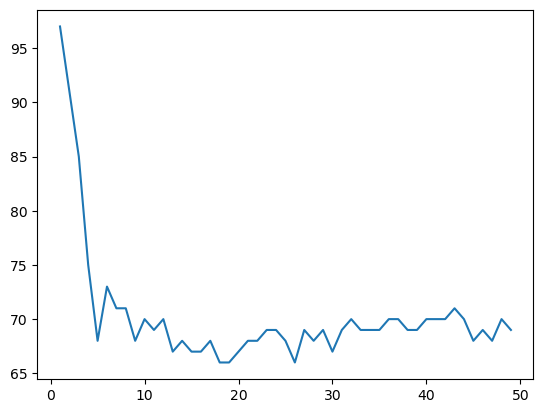

In [32]:
plt.plot(range(1,50),scores)

### Naive_bayes

In [33]:
from sklearn.naive_bayes import GaussianNB

In [34]:
model=GaussianNB()

In [35]:
model.fit(x_train,y_train)

GaussianNB()

In [36]:
y_pred=model.predict(x_test)

In [37]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.73      0.84      0.78       111
           1       0.86      0.77      0.81       146

    accuracy                           0.80       257
   macro avg       0.80      0.80      0.80       257
weighted avg       0.81      0.80      0.80       257



### decision tree

In [38]:
from sklearn.tree import DecisionTreeClassifier

In [39]:
dtree=DecisionTreeClassifier()

In [40]:
dtree.fit(x_train,y_train)

DecisionTreeClassifier()

In [41]:
    y_pred=dtree.predict(x_test)
    print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.98      0.95      0.96       127
           1       0.95      0.98      0.97       130

    accuracy                           0.96       257
   macro avg       0.97      0.96      0.96       257
weighted avg       0.97      0.96      0.96       257



### Random forest

In [42]:
from sklearn.ensemble import RandomForestClassifier

In [43]:
rfc=RandomForestClassifier()

In [44]:
rfc.fit(x_train,y_train)

RandomForestClassifier()

In [45]:
y_pred=rfc.predict(x_test)

In [46]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.98      0.95      0.96       127
           1       0.95      0.98      0.97       130

    accuracy                           0.96       257
   macro avg       0.97      0.96      0.96       257
weighted avg       0.97      0.96      0.96       257



### visulization tree

In [47]:
from sklearn import tree

In [48]:
type(x_train.columns)

pandas.core.indexes.base.Index

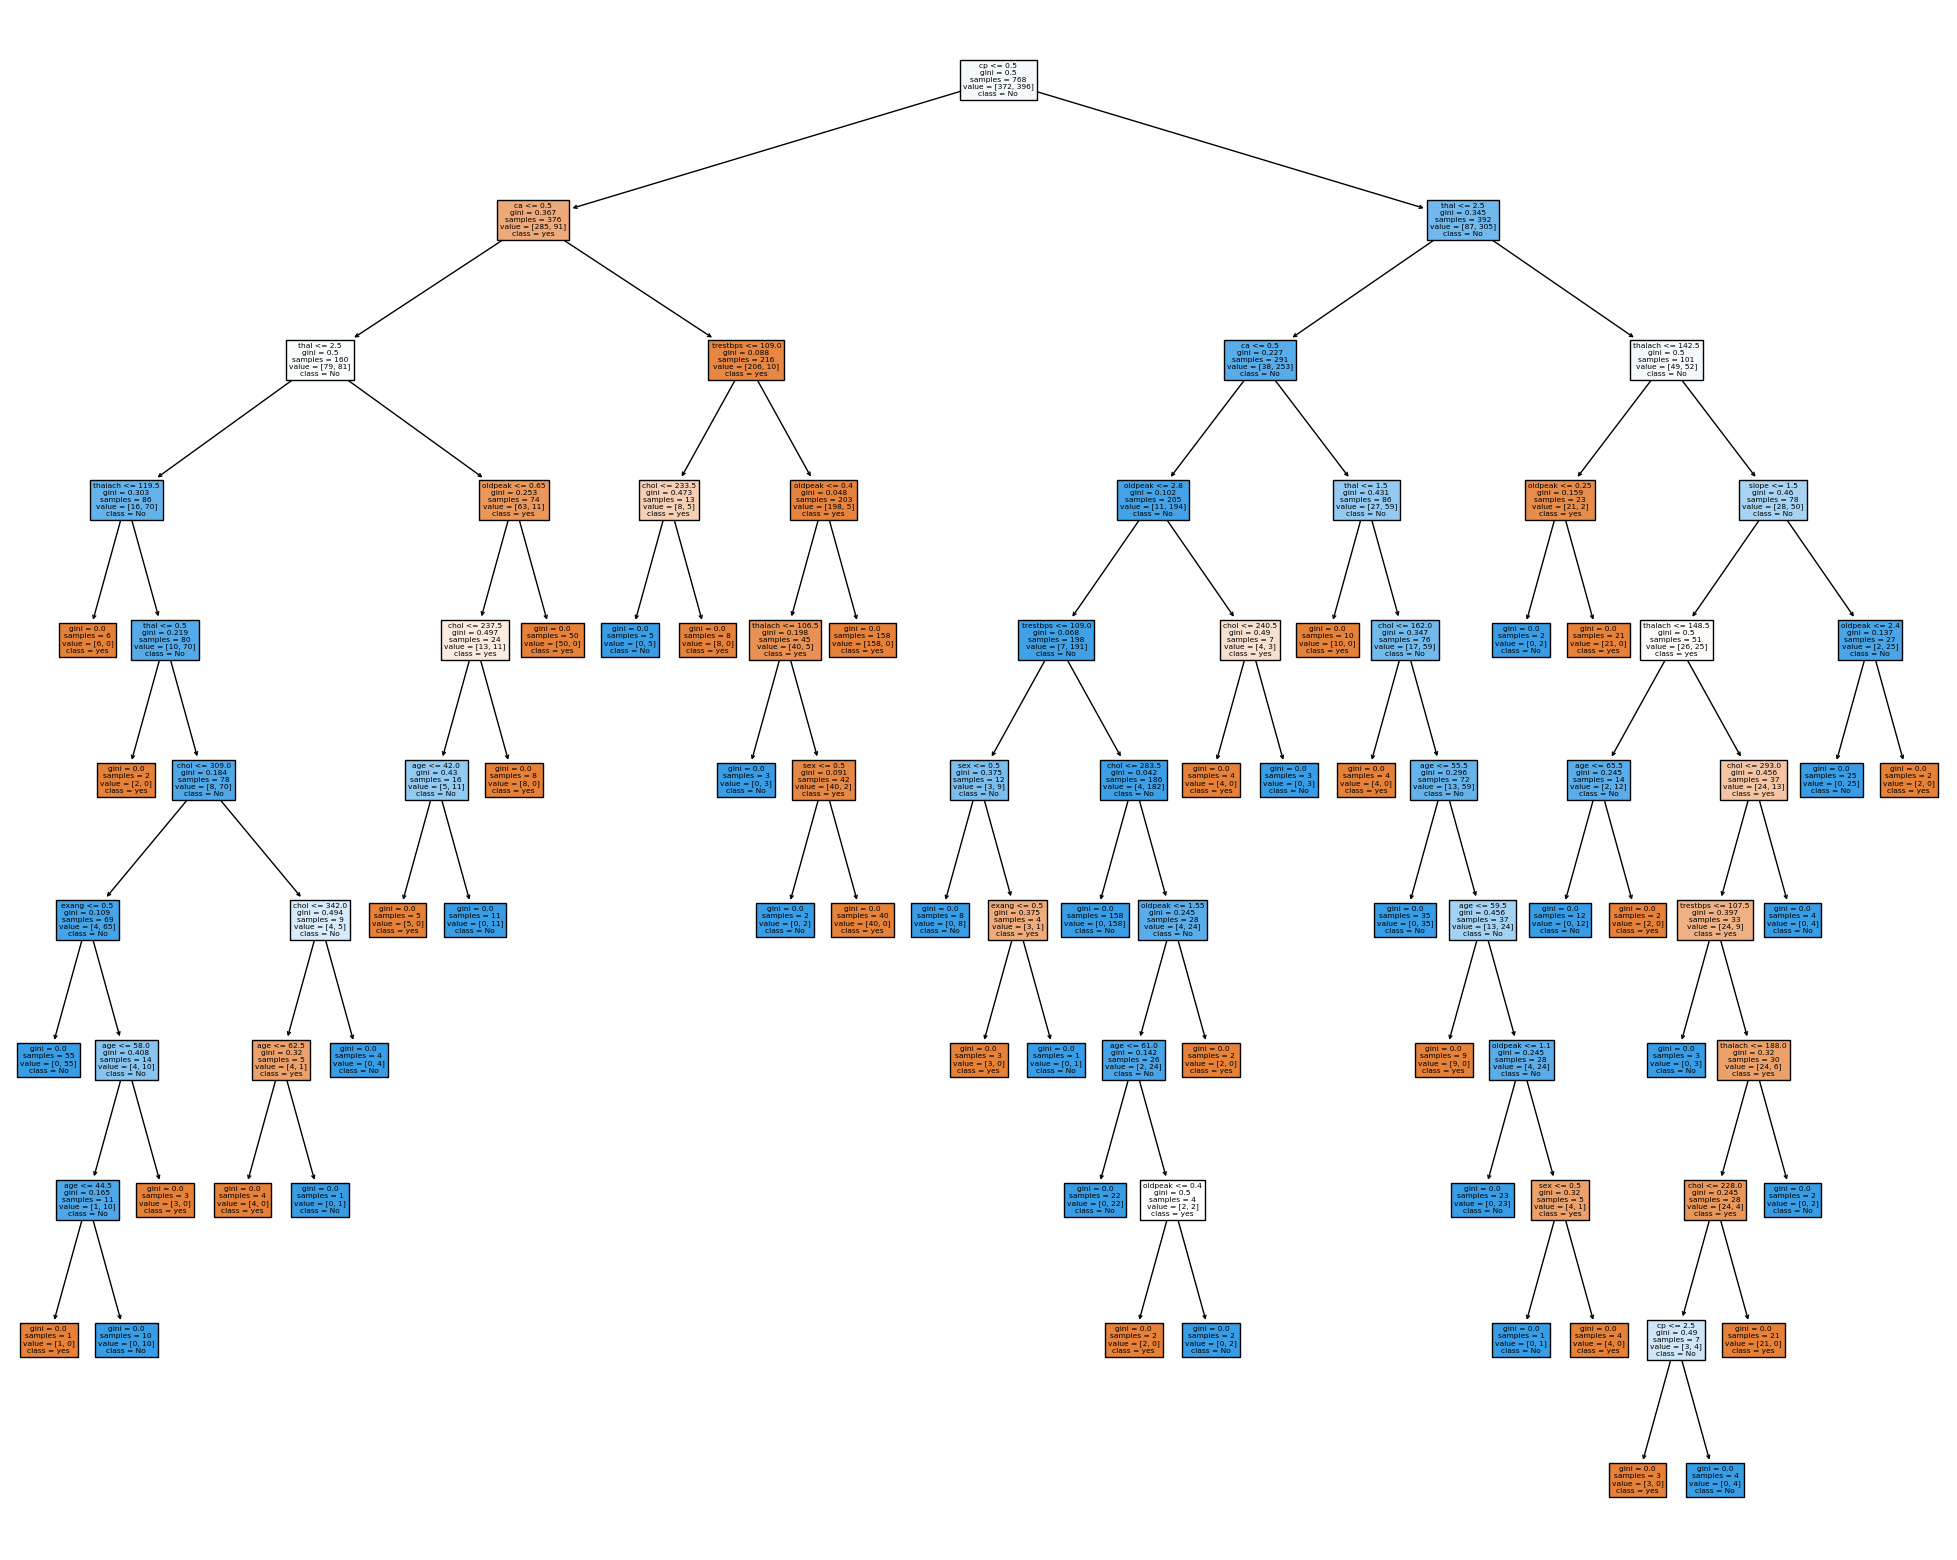

In [49]:
fig=plt.figure(figsize=(25,20))
_=tree.plot_tree(dtree,
                feature_names=x_train.columns,
                class_names=["yes","No"],
                filled=True)